In [2]:
import pandas as pd
df = pd.read_csv("../data/processed/superstore_clean.csv", encoding="latin1")

Dataset Overview

In [8]:
df.shape

(9994, 21)

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Business KPIs

In [3]:
total_sales = df["Sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [4]:
total_profit = df["Profit"].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [5]:
total_orders = df["Order ID"].nunique()
print(f"Total Orders: {total_orders}")

Total Orders: 5009


In [11]:
#Average order value
df["Sales"].sum() / df["Order ID"].nunique()

np.float64(458.6146656618087)

Category Analysis

In [6]:
sales_by_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

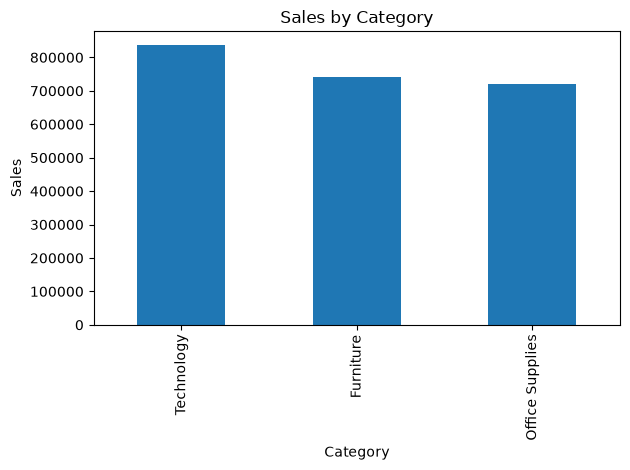

In [7]:
import matplotlib.pyplot as plt

sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [12]:
profit_by_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

profit_by_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

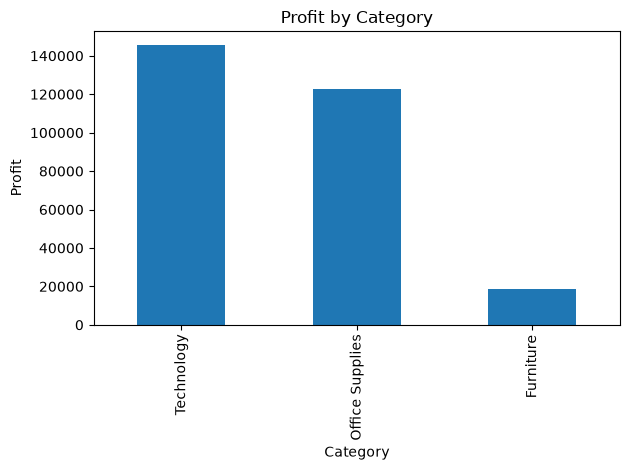

In [13]:
profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

Key Findings

The Technology category outperforms all other categories in both revenue and profit, making it the most valuable segment for the business.

Regional Analysis

In [14]:
#sales by region
df.groupby("Region")["Sales"].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

<Axes: xlabel='Region'>

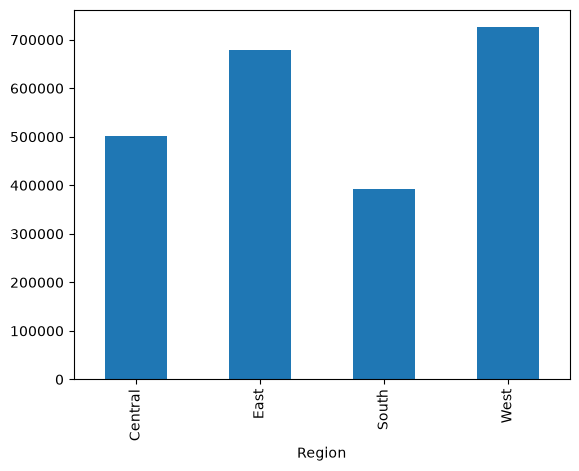

In [17]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")

In [15]:
#Profit by Region
df.groupby("Region")["Profit"].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

<Axes: xlabel='Region'>

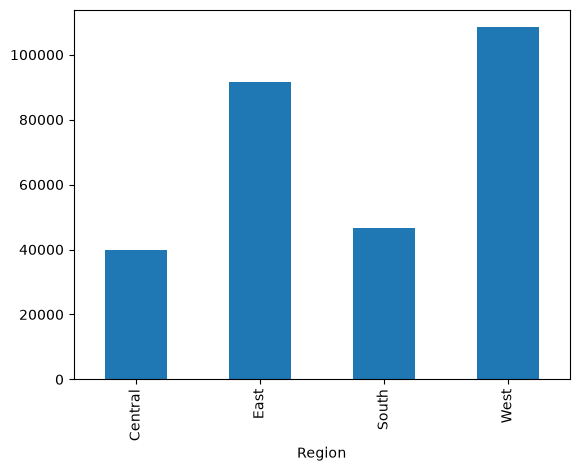

In [16]:
df.groupby("Region")["Profit"].sum().plot(kind="bar")

Key Findings

The West region is the most profitable and highest-revenue generating region, indicating strong market performance in this area.

Customer Segment Analysis

In [18]:
df.groupby("Segment")["Sales"].sum()

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

<Axes: xlabel='Segment'>

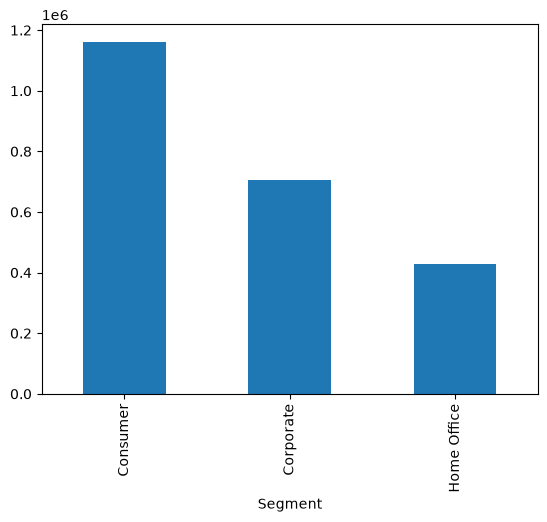

In [19]:
df.groupby("Segment")["Sales"].sum().plot(kind="bar")

In [20]:
df.groupby("Segment")["Profit"].sum()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

<Axes: xlabel='Segment'>

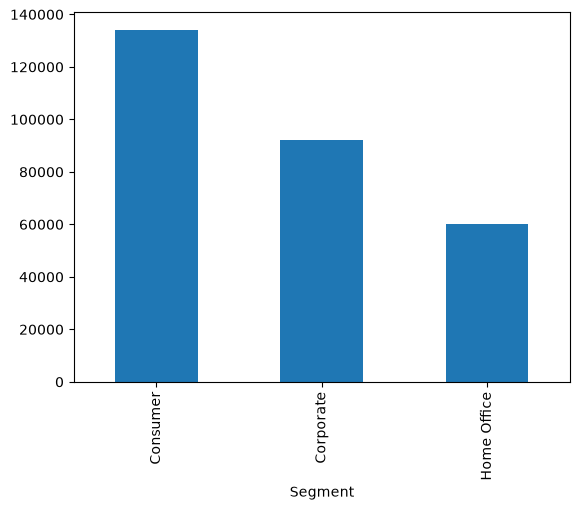

In [21]:
df.groupby("Segment")["Profit"].sum().plot(kind="bar")

Key Findings

The Consumer segment dominates overall performance, contributing the highest share of sales and profit, indicating strong demand from individual customers.

Monthly Sales Trend

In [24]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [25]:
df["Order Date"].dtype

dtype('<M8[us]')

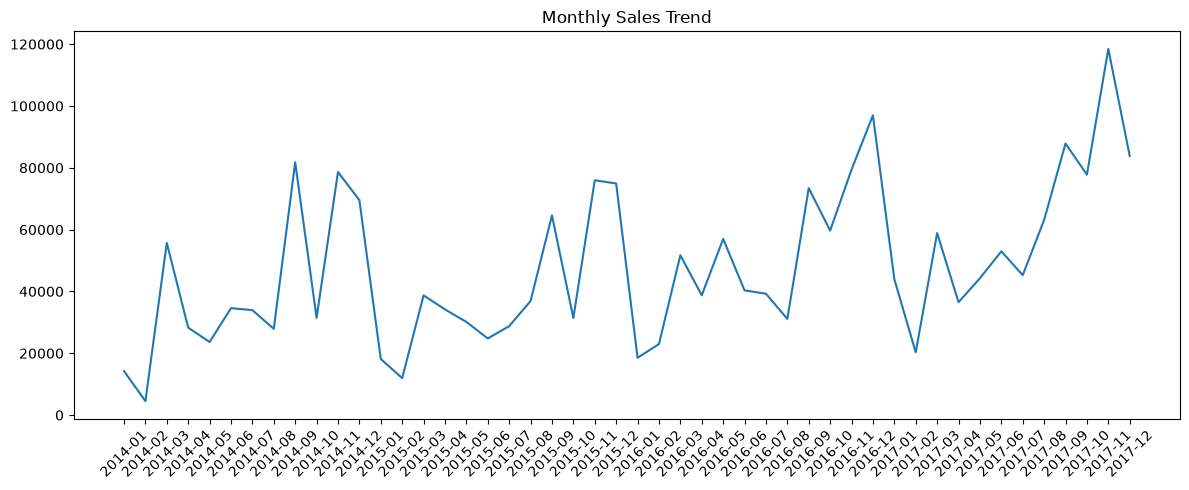

In [37]:
import matplotlib.pyplot as plt

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

Monthly Profit Trend

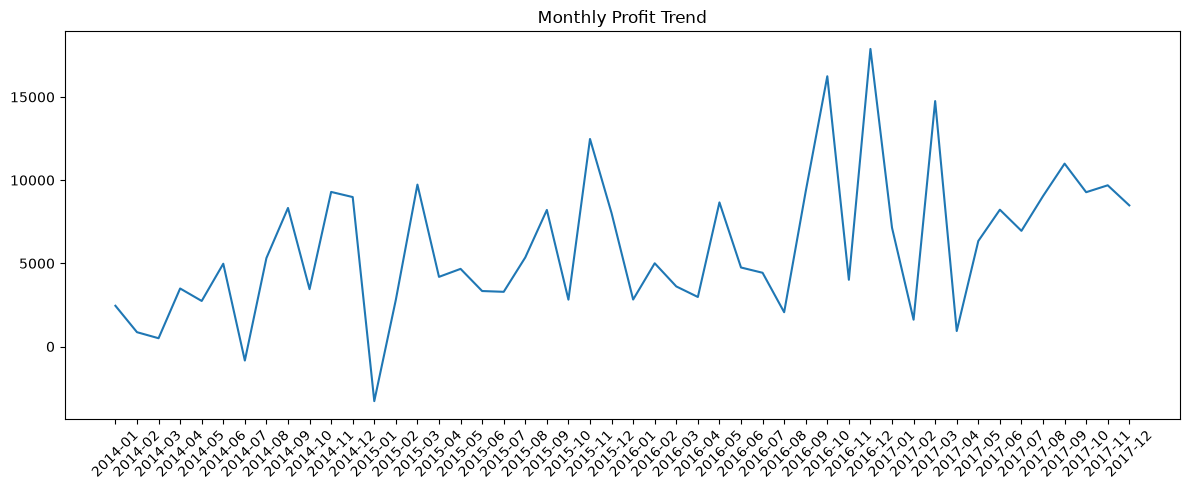

In [38]:
import matplotlib.pyplot as plt

monthly_profit = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Profit"]
      .sum()
)

monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_profit.index, monthly_profit.values)
plt.xticks(rotation=45)
plt.title("Monthly Profit Trend")
plt.tight_layout()
plt.show()

Key Findings

Sales and profit show a clear upward trend over time with significant fluctuations, indicating both growth and seasonality. The repeated peaks and dips suggest periodic variations in demand.

Sales peaked in October 2017, whereas profit was highest in November 2016, suggesting that peak revenue and peak profitability do not always occur in the same period due to variations in discounting, product mix, or cost structure.


Top 10 Products by Sales

In [30]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

<Axes: ylabel='Product Name'>

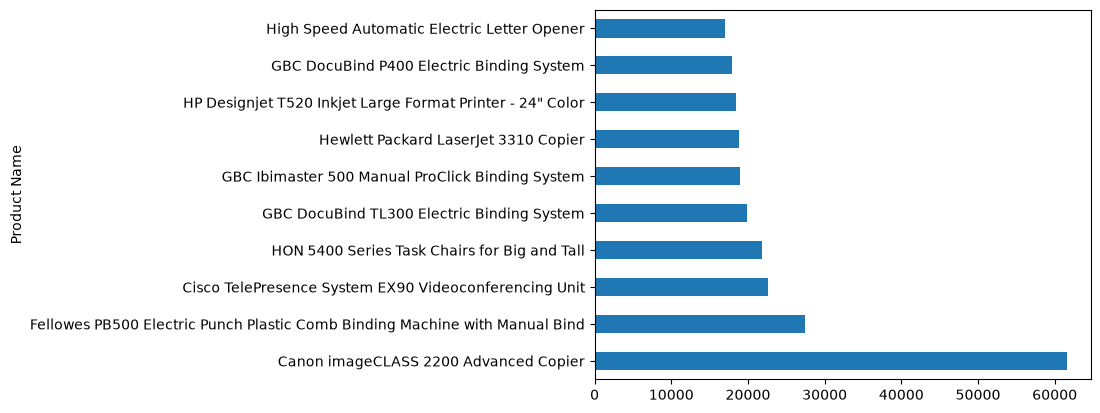

In [31]:
top_products.plot(kind="barh")

Correlation

In [34]:
corr_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

corr_matrix = df[corr_cols].corr()

corr_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


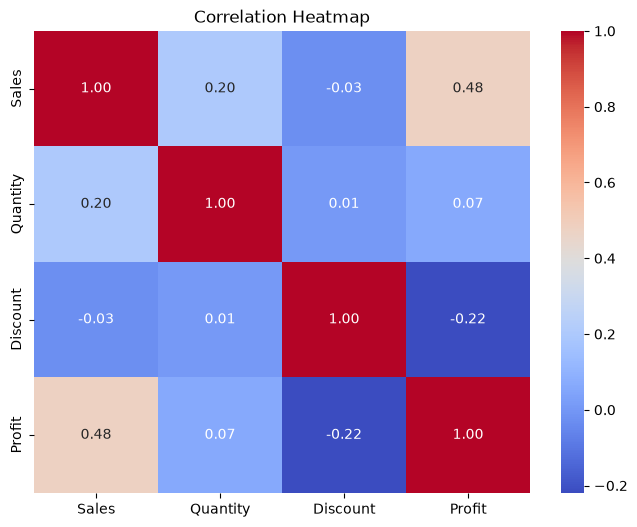

In [36]:
import seaborn as sns


plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Key Findings:
- Sales and Profit are positively correlated.
- Discount shows a negative correlation with Profit.
- Quantity has a positive impact on Sales.